**1. ANN (Artificial Neural Network / Multilayer Perceptron)**

In [13]:
import tensorflow as tf
from tensorflow import keras

# 1. Load data
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# 2. Normalize pixel values from 0-255 to 0-1
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Build the model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# 4. Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train
model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# 6. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9255 - loss: 0.2516 - val_accuracy: 0.9703 - val_loss: 0.1097
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9677 - loss: 0.1040 - val_accuracy: 0.9685 - val_loss: 0.1021
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9777 - loss: 0.0710 - val_accuracy: 0.9772 - val_loss: 0.0826
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9822 - loss: 0.0541 - val_accuracy: 0.9758 - val_loss: 0.0881
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9862 - loss: 0.0431 - val_accuracy: 0.9765 - val_loss: 0.0905
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9789 - loss: 0.0746
Test accuracy: 0.9789000153541565


In [14]:
# Text summary — works for every model, no extra install needed
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

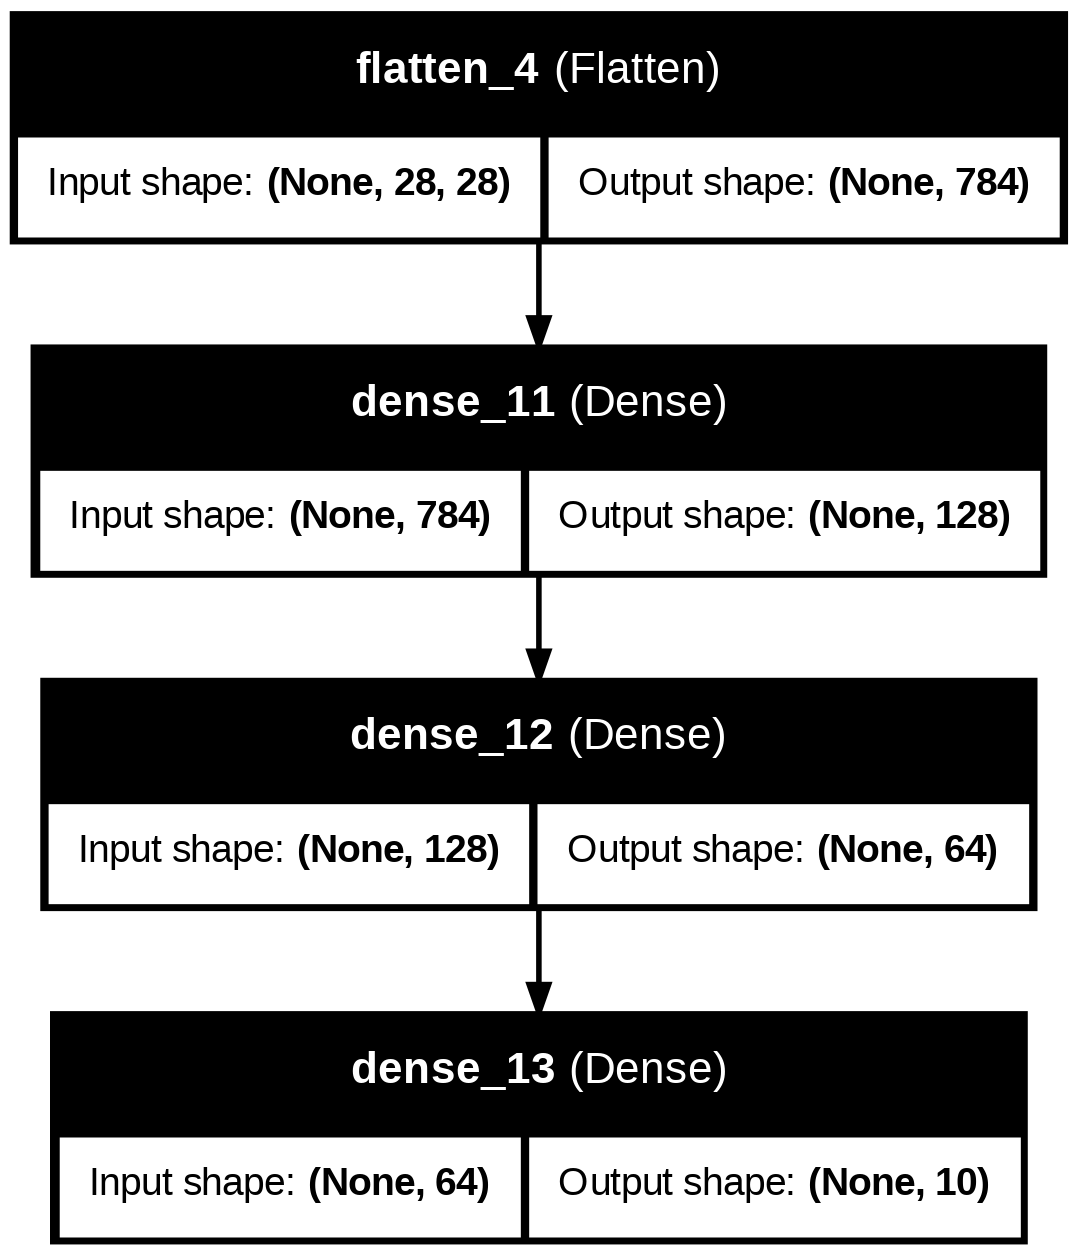

In [15]:
# Visual diagram of the architecture
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model_architecture.png',
           show_shapes=True, show_layer_names=True)

**2. CNN (Convolutional Neural Network)**

In [16]:
import tensorflow as tf
from tensorflow import keras

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

# CNNs expect a channel dimension: (28,28) -> (28,28,1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5, validation_split=0.1)
model.evaluate(x_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 32ms/step - accuracy: 0.9552 - loss: 0.1477 - val_accuracy: 0.9848 - val_loss: 0.0486
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 55s 33ms/step - accuracy: 0.9845 - loss: 0.0487 - val_accuracy: 0.9885 - val_loss: 0.0406
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.9889 - loss: 0.0346 - val_accuracy: 0.9890 - val_loss: 0.0413
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 50s 30ms/step - accuracy: 0.9929 - loss: 0.0226 - val_accuracy: 0.9855 - val_loss: 0.0503
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9941 - loss: 0.0189 - val_accuracy: 0.9887 - val_loss: 0.0396
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9905 - loss: 0.0320


[0.03203484043478966, 0.9904999732971191]

In [17]:
# Text summary — works for every model, no extra install needed
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,792 (1.40 MB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 243,862 (952.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


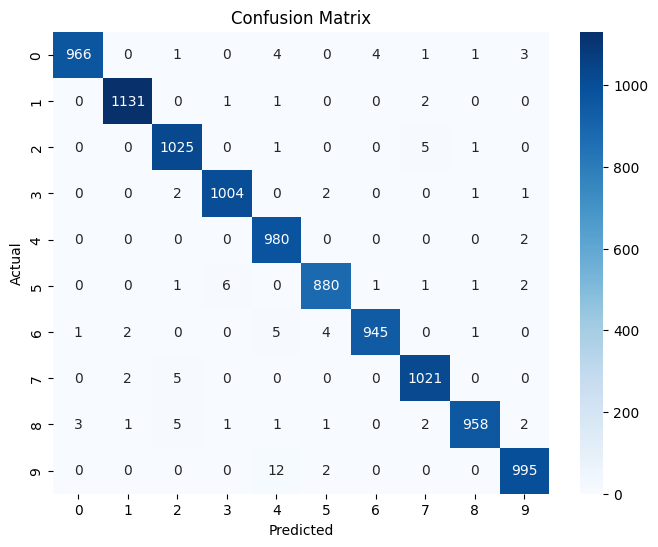

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions (probabilities -> class labels)
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)   # pick the class with highest probability

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Precision, recall, f1 per class
print(classification_report(y_test, y_pred))

**3. RNN / LSTM (sequence data)**

In [19]:
import tensorflow as tf
from tensorflow import keras

num_words = 10000     # only keep the 10,000 most common words
max_len = 200          # every review trimmed/padded to 200 words

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=num_words)

x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

model = keras.Sequential([
    keras.layers.Embedding(num_words, 32, input_length=max_len),
    keras.layers.LSTM(64),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=3, validation_split=0.1, batch_size=64)
model.evaluate(x_test, y_test)

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


352/352 ━━━━━━━━━━━━━━━━━━━━ 52s 141ms/step - accuracy: 0.7756 - loss: 0.4706 - val_accuracy: 0.8620 - val_loss: 0.3404
Epoch 2/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 51s 144ms/step - accuracy: 0.8942 - loss: 0.2678 - val_accuracy: 0.8624 - val_loss: 0.3208
Epoch 3/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - accuracy: 0.9214 - loss: 0.2081 - val_accuracy: 0.8672 - val_loss: 0.3151
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.8646 - loss: 0.3228


[0.3227594792842865, 0.8646000027656555]

In [20]:
# Text summary — works for every model, no extra install needed
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,034,693 (3.95 MB)

 Trainable params: 344,897 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 689,796 (2.63 MB)

In [21]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_pred_probs = model.predict(x_test)
y_pred = (y_pred_probs > 0.5).astype(int)   # threshold at 0.5 for binary classification

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print("True Negatives:", tn, "| False Positives:", fp)
print("False Negatives:", fn, "| True Positives:", tp)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step
Confusion Matrix:
[[10922  1578]
 [ 1807 10693]]
True Negatives: 10922 | False Positives: 1578
False Negatives: 1807 | True Positives: 10693
Precision: 0.87
Recall: 0.86
F1 Score: 0.86


**4. GAN (Generative Adversarial Network)**

In [22]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

(x_train, _), (_, _) = keras.datasets.mnist.load_data()
x_train = (x_train.astype('float32') - 127.5) / 127.5   # scale to [-1, 1]
x_train = x_train.reshape(-1, 28, 28, 1)

latent_dim = 100

# Generator: random noise -> fake image
generator = keras.Sequential([
    keras.layers.Dense(7*7*128, input_dim=latent_dim),
    keras.layers.Reshape((7,7,128)),
    keras.layers.Conv2DTranspose(64, (4,4), strides=2, padding='same', activation='relu'),
    keras.layers.Conv2DTranspose(1, (4,4), strides=2, padding='same', activation='tanh')
])

# Discriminator: image -> real or fake
discriminator = keras.Sequential([
    keras.layers.Conv2D(64, (4,4), strides=2, padding='same', input_shape=(28,28,1)),
    keras.layers.LeakyReLU(0.2),
    keras.layers.Conv2D(128, (4,4), strides=2, padding='same'),
    keras.layers.LeakyReLU(0.2),
    keras.layers.Flatten(),
    keras.layers.Dense(1, activation='sigmoid')
])
discriminator.compile(optimizer='adam', loss='binary_crossentropy')

# Combined model: freeze discriminator, train generator to fool it
discriminator.trainable = False
gan_input = keras.Input(shape=(latent_dim,))
fake_image = generator(gan_input)
gan_output = discriminator(fake_image)
gan = keras.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')

# Training loop (simplified, one epoch's worth of logic)
batch_size = 64
noise = np.random.normal(0, 1, (batch_size, latent_dim))
fake_images = generator.predict(noise)
real_images = x_train[np.random.randint(0, x_train.shape[0], batch_size)]

# Train discriminator: real=1, fake=0
discriminator.trainable = True
discriminator.train_on_batch(real_images, np.ones((batch_size,1)))
discriminator.train_on_batch(fake_images, np.zeros((batch_size,1)))

# Train generator: wants discriminator to say fake images are real (label=1)
discriminator.trainable = False
noise = np.random.normal(0, 1, (batch_size, latent_dim))
gan.train_on_batch(noise, np.ones((batch_size,1)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array(0.69097817, dtype=float32)

**Wrap-up block**

In [24]:
# Dropout — randomly disables neurons during training to prevent overfitting
keras.layers.Dropout(0.3)   # drops 30% of neurons each pass

# Batch Normalization — normalizes activations between layers, stabilizes/speeds up training
keras.layers.BatchNormalization()

# EarlyStopping — stops training automatically when validation loss stops improving
keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

**Part 3: Transformer Code**

3a. Self-Attention from scratch

In [25]:
import tensorflow as tf
from tensorflow import keras

# Toy sequence: 4 words, each represented as a vector of size 8
seq_len = 4
embed_dim = 8

x = tf.random.normal((1, seq_len, embed_dim))  # (batch, words, embedding)

# Multi-head attention layer (built into Keras, does Q/K/V internally)
mha = keras.layers.MultiHeadAttention(num_heads=2, key_dim=embed_dim)

# Self-attention: query, key, and value all come from the SAME input
output = mha(query=x, key=x, value=x)

print(output.shape)  # (1, 4, 8) - same shape as input, but each word's
                      # vector is now a blend of all other words' info

(1, 4, 8)


3b. A full Transformer block (encoder layer)

In [26]:
class TransformerBlock(keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim):
        super().__init__()
        self.att = keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            keras.layers.Dense(ff_dim, activation='relu'),
            keras.layers.Dense(embed_dim)
        ])
        self.norm1 = keras.layers.LayerNormalization()
        self.norm2 = keras.layers.LayerNormalization()

    def call(self, x):
        attn_output = self.att(x, x, x)
        x = self.norm1(x + attn_output)        # residual connection + normalize
        ffn_output = self.ffn(x)
        x = self.norm2(x + ffn_output)          # residual connection + normalize
        return x

3c. Practical demo: using a pretrained transformer (what people actually do day to day)

In [27]:
# pip install transformers
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
print(classifier("This course is actually explained really well."))

generator = pipeline("text-generation", model="gpt2")
print(generator("Deep learning is", max_length=30, num_return_sequences=1))

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.9997745156288147}]


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Deep learning is a fundamental science and is at the heart of the computer industry. It uses computer vision to better understand and understand complex problems.\n\nResearch has been done on AI and neural network technologies since the 1990s. It's been used for more than 50 years, and is still used today by many industries including agriculture and healthcare.\n\nThe goal of this paper is to provide a framework for working with AI to understand and improve on the existing techniques and ways to build and build new AI solutions.\n\nHow do I build a machine learning algorithm that can learn to solve complex problems?\n\nYou can either build a model that can learn to solve problems yourself or you can use a machine learning algorithm that can learn to solve problems for you. When doing both, you'll want to use a machine learning system that can learn to solve problems for you.\n\nThe current models for learning to solve problems for humans are based on the concepts k